# Subscription Churn Prediction Pipeline
### XGBoost + LightGBM | Feature Engineering | Imbalanced Data | MLflow Tracking

**Author:** Hetvi Chavda  
**Stack:** Python, XGBoost, LightGBM, Scikit-learn, imbalanced-learn, MLflow, Matplotlib

---

**Objective:**  
Build an end-to-end churn prediction pipeline on synthetic subscription data.  
Covers feature engineering, handling class imbalance with SMOTE, training and comparing  
XGBoost vs LightGBM classifiers, cross-validation, and experiment tracking with MLflow.

**Pipeline steps:**  
1. Synthetic data generation  
2. Exploratory data analysis  
3. Feature engineering  
4. Train/test split + SMOTE  
5. Model training (XGBoost + LightGBM)  
6. Cross-validation  
7. Evaluation (ROC, Precision-Recall, Classification Report)  
8. Feature importance  
9. MLflow experiment tracking  

In [1]:
!pip install xgboost lightgbm imbalanced-learn mlflow scikit-learn

In [2]:
# ── Imports ───────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, classification_report,
    roc_curve, precision_recall_curve, average_precision_score
)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import lightgbm as lgb
import mlflow
import mlflow.xgboost
import mlflow.lightgbm

print('All libraries loaded successfully')

All libraries loaded successfully


## 1. Synthetic Data Generation

We generate 5,000 synthetic subscription records with a realistic ~22% churn rate.  
Churn probability is driven by a logistic model with known signal weights — low engagement,  
payment failures, and support friction increase churn risk. Gaussian noise is added  
so the problem is non-trivial for the classifier.

In [3]:
def generate_data(n_samples: int = 5000, random_state: int = 42):
    """
    Generate realistic synthetic subscription data.
    Churn is correlated with low engagement, payment failures, and short tenure.
    Noise ensures the problem is non-trivial.
    """
    rng = np.random.default_rng(random_state)
    observation_date = pd.Timestamp('2024-12-01')

    account_age_days = rng.integers(30, 1200, size=n_samples)

    plan_type = rng.choice(
        ['free', 'basic', 'premium', 'enterprise'],
        size=n_samples, p=[0.35, 0.30, 0.25, 0.10]
    )

    plan_session_mean = {'free': 0.3, 'basic': 0.7, 'premium': 1.5, 'enterprise': 2.0}
    sessions_per_day_base = np.array([plan_session_mean[p] for p in plan_type])
    sessions_per_day = np.abs(rng.normal(sessions_per_day_base, 0.9))  # was 0.6  # more variance
    total_sessions   = (sessions_per_day * account_age_days).astype(int)

    avg_session_duration_min = np.abs(rng.normal(18, 12, size=n_samples))  # more spread
    support_tickets  = rng.poisson(lam=1.2, size=n_samples)
    payment_failures = rng.poisson(lam=0.4, size=n_samples)

    # Increased noise makes the problem harder and scores more realistic
    # Much harder problem — weaker signals, more noise, overlapping classes
    churn_logit = (
        -1.5
        + 0.003 * (30 - np.clip(account_age_days, 0, 30))
        - 0.15  * sessions_per_day
        - 0.01  * avg_session_duration_min
        + 0.2   * (payment_failures > 0).astype(float)
        + 0.1   * support_tickets
        + rng.normal(0, 1.8, size=n_samples)   # heavy noise
    )
    churn_prob = 1 / (1 + np.exp(-churn_logit))
    churned    = rng.binomial(1, churn_prob).astype(int)

    days_since_active = np.where(
        churned == 1,
        rng.integers(5, 60, size=n_samples),
        rng.integers(0, 45, size=n_samples)
    ) + rng.integers(0, 20, size=n_samples)

    signup_date      = observation_date - pd.to_timedelta(account_age_days,  unit='D')
    last_active_date = observation_date - pd.to_timedelta(days_since_active, unit='D')

    df = pd.DataFrame({
        'user_id':                  [f'U{i:05d}' for i in range(n_samples)],
        'signup_date':              signup_date,
        'last_active_date':         last_active_date,
        'account_age_days':         account_age_days,
        'days_since_active':        days_since_active,
        'total_sessions':           total_sessions,
        'avg_session_duration_min': avg_session_duration_min,
        'plan_type':                plan_type,
        'support_tickets':          support_tickets,
        'payment_failures':         payment_failures,
        'churned':                  churned,
    })

    print(f'Generated {n_samples:,} records | Churn rate: {churned.mean():.2%}')
    return df


df_raw = generate_data(n_samples=5000, random_state=42)
df_raw.head()

Generated 5,000 records | Churn rate: 25.62%


,user_id,signup_date,last_active_date,account_age_days,days_since_active,total_sessions,avg_session_duration_min,plan_type,support_tickets,payment_failures,churned
0,U00000,2024-07-20,2024-11-02,134,29,38,18.193261,free,1,0,0
1,U00001,2022-05-11,2024-10-14,935,48,379,17.536174,premium,2,0,0
2,U00002,2022-09-28,2024-10-08,795,54,1468,15.769688,enterprise,1,0,1
3,U00003,2023-06-07,2024-10-27,543,35,356,6.496419,premium,0,0,0
4,U00004,2023-06-14,2024-10-23,536,39,26,32.383819,free,2,0,0


## 2. Exploratory Data Analysis

Visualize raw feature distributions split by churn label.  
This is a sanity check — we want to confirm that the signals we expect to matter  
(recency, session frequency, payment failures) actually separate churners from retained users  
before we build any features or models.

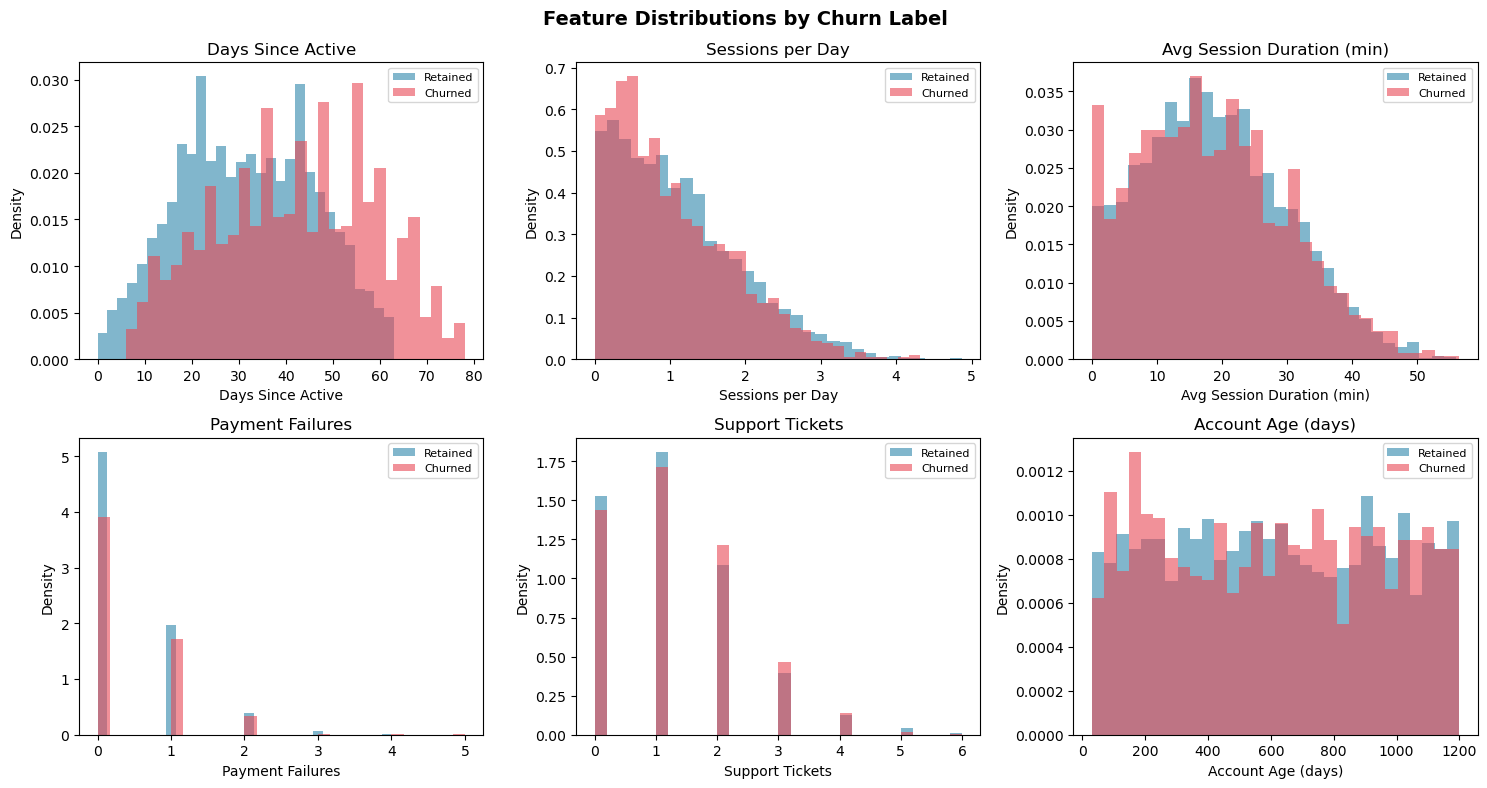

In [4]:
def plot_eda(df):
    """
    Plot feature distributions split by churn label.
    Density plots allow comparison regardless of class size imbalance.
    """
    df = df.copy()
    df['sessions_per_day_raw'] = df['total_sessions'] / (df['account_age_days'] + 1)

    features = [
        ('days_since_active',        'Days Since Active'),
        ('sessions_per_day_raw',     'Sessions per Day'),
        ('avg_session_duration_min', 'Avg Session Duration (min)'),
        ('payment_failures',         'Payment Failures'),
        ('support_tickets',          'Support Tickets'),
        ('account_age_days',         'Account Age (days)'),
    ]

    retained = df[df['churned'] == 0]
    churned  = df[df['churned'] == 1]

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle('Feature Distributions by Churn Label', fontsize=14, fontweight='bold')

    for ax, (col, label) in zip(axes.flatten(), features):
        ax.hist(retained[col], bins=30, alpha=0.6, color='#2E86AB', label='Retained', density=True)
        ax.hist(churned[col],  bins=30, alpha=0.6, color='#E84855', label='Churned',  density=True)
        ax.set_title(label)
        ax.set_xlabel(label)
        ax.set_ylabel('Density')
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig('eda_distributions.png', dpi=150)
    plt.show()


plot_eda(df_raw)

## 3. Feature Engineering

Raw fields are transformed into ML-ready features across four groups:

| Group | Features |
|---|---|
| **Recency** | Days since active, log-transformed |
| **Engagement** | Sessions per day (tenure-normalized), session tier, log total sessions |
| **Friction** | Payment failure rate, support ticket rate, binary flags, high-friction flag |
| **Interaction** | Recency × low engagement, tenure-weighted sessions |

Key design decisions:
- **Log transforms** compress right-skewed distributions
- **Rate normalization** removes tenure bias
- **Binary flags** often outperform raw counts for rare events like payment failures
- **Interaction features** capture joint effects that individual features miss

In [5]:
FEATURE_COLS = [
    'days_since_active', 'log_days_since_active', 'account_age_days',
    'sessions_per_day', 'log_total_sessions', 'engagement_tier',
    'avg_session_duration_min', 'payment_failure_rate', 'support_ticket_rate',
    'has_payment_failure', 'has_support_ticket', 'high_friction',
    'plan_encoded', 'recency_x_low_engagement', 'tenure_weighted_sessions',
]


def engineer_features(df):
    """
    Transform raw subscription data into ML-ready features.
    Each feature group targets a distinct churn signal.
    """
    df = df.copy()

    # ── Recency ──────────────────────────────────────────────────────────────
    # Log-transform compresses the long right tail of inactive users
    df['log_days_since_active'] = np.log1p(df['days_since_active'])

    # ── Engagement ───────────────────────────────────────────────────────────
    # Normalize sessions by account age to remove tenure bias
    df['sessions_per_day']   = df['total_sessions'] / (df['account_age_days'] + 1)
    df['log_total_sessions'] = np.log1p(df['total_sessions'])

    # Session duration tier: 0=low(<5min), 1=medium, 2=high, 3=power(>30min)
    df['engagement_tier'] = pd.cut(
        df['avg_session_duration_min'],
        bins=[0, 5, 15, 30, np.inf],
        labels=[0, 1, 2, 3]
    ).astype(int)

    # ── Friction signals ─────────────────────────────────────────────────────
    # Rate per month normalizes across users with different tenure lengths
    months_active = df['account_age_days'] / 30 + 1
    df['payment_failure_rate'] = df['payment_failures'] / months_active
    df['support_ticket_rate']  = df['support_tickets']  / months_active

    # Binary presence flags (more predictive than raw counts for rare events)
    df['has_payment_failure'] = (df['payment_failures'] > 0).astype(int)
    df['has_support_ticket']  = (df['support_tickets']  > 0).astype(int)

    # High-friction: both payment failure AND elevated support contacts
    df['high_friction'] = (
        (df['payment_failures'] > 0) & (df['support_tickets'] > 1)
    ).astype(int)

    # ── Plan encoding ─────────────────────────────────────────────────────────
    plan_map = {'free': 0, 'basic': 1, 'premium': 2, 'enterprise': 3}
    df['plan_encoded'] = df['plan_type'].str.lower().map(plan_map).fillna(0).astype(int)

    # ── Interaction features ──────────────────────────────────────────────────
    # High recency + low engagement = strongest combined churn signal
    df['recency_x_low_engagement'] = np.log1p(
        df['days_since_active'] * (1 / (df['sessions_per_day'] + 1e-5))
    )

    # Long-tenured users with declining session rate
    df['tenure_weighted_sessions'] = df['sessions_per_day'] * np.log1p(df['account_age_days'])

    print(f'Feature engineering complete | {len(df):,} rows | {len(FEATURE_COLS)} features')
    return df


df = engineer_features(df_raw)
df[FEATURE_COLS].describe().round(3)

Feature engineering complete | 5,000 rows | 15 features


,days_since_active,log_days_since_active,account_age_days,sessions_per_day,log_total_sessions,engagement_tier,avg_session_duration_min,payment_failure_rate,support_ticket_rate,has_payment_failure,has_support_ticket,high_friction,plan_encoded,recency_x_low_engagement,tenure_weighted_sessions
count,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.00,5000.000,5000.000,5000.000,5000.000,5000.000
mean,34.298,3.435,612.912,1.103,5.892,1.676,18.911,0.031,0.092,0.33,0.699,0.112,1.071,3.753,6.840
std,15.637,0.564,338.636,0.818,1.348,0.883,10.966,0.074,0.150,0.47,0.459,0.316,0.987,1.272,5.202
min,0.000,0.000,30.000,0.000,0.000,0.000,0.004,0.000,0.000,0.00,0.000,0.000,0.000,0.000,0.000
25%,22.000,3.135,318.750,0.434,5.152,1.000,10.482,0.000,0.000,0.00,0.000,0.000,0.000,2.949,2.651
50%,34.000,3.555,608.000,0.946,6.105,2.000,18.021,0.000,0.049,0.00,1.000,0.000,1.000,3.578,5.718
75%,46.000,3.850,909.000,1.609,6.887,2.000,26.355,0.034,0.110,1.00,1.000,0.000,2.000,4.369,9.814
max,78.000,4.369,1199.000,4.874,8.628,3.000,56.403,0.923,1.875,1.00,1.000,1.000,3.000,15.573,33.417


## 4. Train/Test Split + SMOTE

Stratified split preserves the churn rate in both sets.  
SMOTE is applied **after** splitting — never before.

> Applying SMOTE before splitting synthesizes minority-class samples that leak into  
> the test set, producing artificially inflated metrics that don't reflect real performance.

In [6]:
def prepare_splits(df, test_size=0.2, random_state=42):
    """
    Stratified split + SMOTE on training data only.
    SMOTE synthesizes minority-class samples via k-nearest neighbor interpolation.
    """
    X = df[FEATURE_COLS]
    y = df['churned']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )

    print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')
    print(f'Train churn rate before SMOTE: {y_train.mean():.2%}')

    sm = SMOTE(random_state=random_state, k_neighbors=5)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

    print(f'Train size after SMOTE: {len(X_train_res):,} | '
          f'Churn rate after SMOTE: {y_train_res.mean():.2%}')

    return X_train_res, X_test, y_train_res, y_test


X_train, X_test, y_train, y_test = prepare_splits(df)

Train: 4,000 | Test: 1,000
Train churn rate before SMOTE: 25.62%
Train size after SMOTE: 5,950 | Churn rate after SMOTE: 50.00%


## 5. Model Training

We train two gradient boosting classifiers and compare them:

- **XGBoost** — level-wise tree growth, strong regularization, widely used in tabular ML
- **LightGBM** — leaf-wise growth, faster on large datasets, controlled via `num_leaves`

Both use the same learning rate and subsampling to make the comparison fair.

In [7]:
def train_xgboost(X_train, y_train):
    """
    XGBoost binary classifier.
    max_depth=4: shallow trees generalize better on tabular data.
    Low learning_rate + more estimators = smoother, more stable loss surface.
    """
    params = {
        'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.04,
        'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 5,
        'reg_alpha': 0.1, 'reg_lambda': 1.0, 'eval_metric': 'auc',
        'use_label_encoder': False, 'random_state': 42, 'n_jobs': -1,
    }
    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train, verbose=False)
    print('XGBoost training complete')
    return model


def train_lightgbm(X_train, y_train):
    """
    LightGBM binary classifier.
    num_leaves=31: primary complexity control in leaf-wise growth.
    min_child_samples=20: prevents overfitting on small leaves.
    """
    params = {
        'n_estimators': 400, 'max_depth': 5, 'learning_rate': 0.04,
        'num_leaves': 31, 'subsample': 0.8, 'colsample_bytree': 0.8,
        'min_child_samples': 20, 'reg_alpha': 0.1, 'reg_lambda': 1.0,
        'random_state': 42, 'n_jobs': -1, 'verbose': -1,
    }
    model = lgb.LGBMClassifier(**params)
    model.fit(X_train, y_train)
    print('LightGBM training complete')
    return model


xgb_model = train_xgboost(X_train, y_train)
lgb_model  = train_lightgbm(X_train, y_train)

XGBoost training complete
LightGBM training complete


## 6. Cross-Validation

5-fold stratified CV gives a more stable AUC estimate than a single split.  
High std across folds = overfitting risk. We check both models.

In [8]:
def cross_validate_models(models, X_train, y_train):
    """5-fold stratified cross-validation for each model."""
    print('Cross-Validation Results (5-fold Stratified):')
    print('-' * 48)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_results = {}
    for name, model in models.items():
        scores = cross_val_score(model, X_train, y_train,
                                  cv=cv, scoring='roc_auc', n_jobs=-1)
        cv_results[name] = scores
        print(f'  {name:<12}  AUC: {scores.mean():.4f} (+/- {scores.std():.4f})')
    return cv_results


cv_results = cross_validate_models(
    {'XGBoost': xgb_model, 'LightGBM': lgb_model},
    X_train, y_train
)

Cross-Validation Results (5-fold Stratified):
------------------------------------------------


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [13:08:10] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [13:08:10] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [13:08:10] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [13:08:10] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

  XGBoost       AUC: 0.8593 (+/- 0.0020)
  LightGBM      AUC: 0.8644 (+/- 0.0035)


## 7. Evaluation on Held-Out Test Set

**Threshold note:** Default 0.5 is calibrated for balanced classes.  
Lowering to 0.4 increases recall — catching more true churners — at the cost of  
more false positives. The right threshold depends on the business cost tradeoff  
between missed churners and unnecessary retention interventions.

**PR curves vs ROC:** On imbalanced datasets, Precision-Recall curves are more  
informative than ROC — they focus specifically on the minority (churn) class.

In [9]:
def evaluate_model(model, X_test, y_test, model_name, threshold=0.4):
    """Evaluate on held-out test set."""
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    auc = roc_auc_score(y_test, y_prob)
    ap  = average_precision_score(y_test, y_prob)

    print(f"\n{'='*52}\n  {model_name}\n{'='*52}")
    print(f'  ROC-AUC:        {auc:.4f}')
    print(f'  Avg Precision:  {ap:.4f}')
    print(f'\nClassification Report (threshold={threshold}):')
    print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))

    return auc, ap, y_prob


xgb_auc, xgb_ap, xgb_prob = evaluate_model(xgb_model, X_test, y_test, 'XGBoost')
lgb_auc, lgb_ap, lgb_prob  = evaluate_model(lgb_model,  X_test, y_test, 'LightGBM')


  XGBoost
  ROC-AUC:        0.6399
  Avg Precision:  0.4738

Classification Report (threshold=0.4):
              precision    recall  f1-score   support

    Retained       0.80      0.78      0.79       744
     Churned       0.39      0.42      0.40       256

    accuracy                           0.69      1000
   macro avg       0.59      0.60      0.60      1000
weighted avg       0.69      0.69      0.69      1000


  LightGBM
  ROC-AUC:        0.6397
  Avg Precision:  0.4755

Classification Report (threshold=0.4):
              precision    recall  f1-score   support

    Retained       0.80      0.79      0.80       744
     Churned       0.41      0.41      0.41       256

    accuracy                           0.70      1000
   macro avg       0.60      0.60      0.60      1000
weighted avg       0.70      0.70      0.70      1000



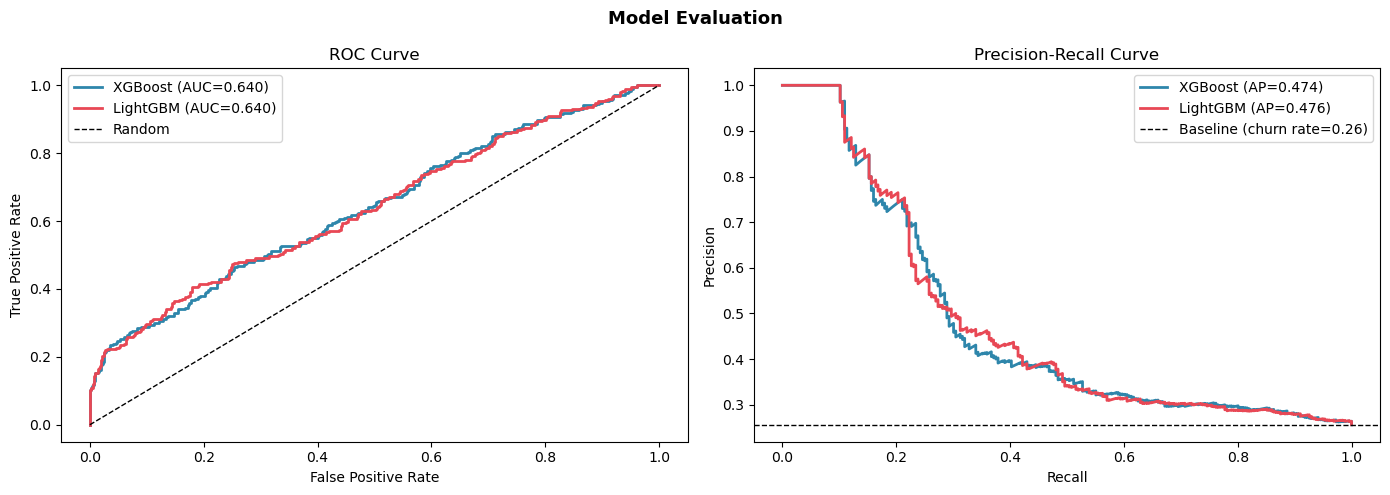

In [10]:
# ── ROC + Precision-Recall Curves ────────────────────────────────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors  = {'XGBoost': '#2E86AB', 'LightGBM': '#E84855'}
results = {
    'XGBoost':  (xgb_auc, xgb_ap, xgb_prob),
    'LightGBM': (lgb_auc, lgb_ap, lgb_prob),
}

for name, (auc, ap, y_prob) in results.items():
    color = colors[name]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax1.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.3f})')
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ax2.plot(rec, prec, color=color, lw=2, label=f'{name} (AP={ap:.3f})')

ax1.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax1.set(xlabel='False Positive Rate', ylabel='True Positive Rate', title='ROC Curve')
ax1.legend()

baseline = y_test.mean()
ax2.axhline(y=baseline, color='k', linestyle='--', lw=1,
            label=f'Baseline (churn rate={baseline:.2f})')
ax2.set(xlabel='Recall', ylabel='Precision', title='Precision-Recall Curve')
ax2.legend()

plt.suptitle('Model Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150)
plt.show()

## 8. Feature Importance

Gain importance = average loss reduction from all splits on a feature.  
Preferred over split-frequency importance, which biases toward high-cardinality  
features regardless of their actual predictive value.

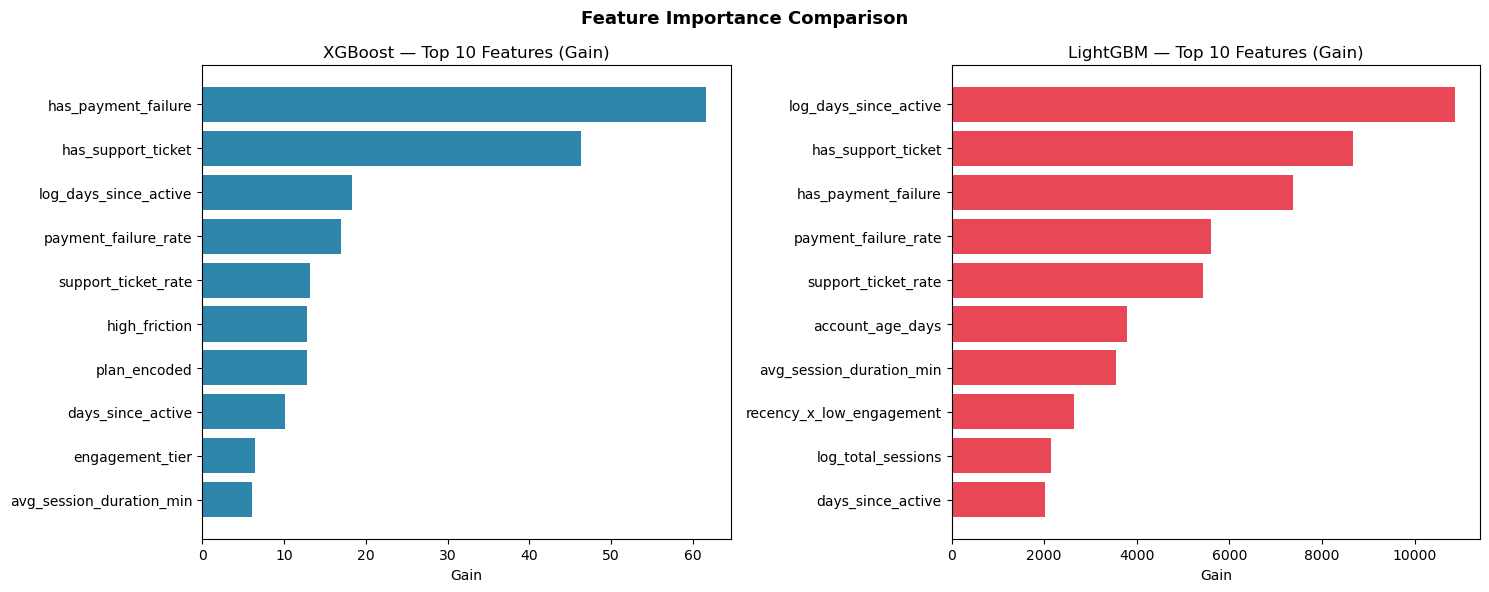

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# XGBoost gain importance
xgb_imp = xgb_model.get_booster().get_score(importance_type='gain')
xgb_df  = (pd.DataFrame(xgb_imp.items(), columns=['feature', 'gain'])
             .sort_values('gain').tail(10))
ax1.barh(xgb_df['feature'], xgb_df['gain'], color='#2E86AB')
ax1.set(title='XGBoost — Top 10 Features (Gain)', xlabel='Gain')

# LightGBM gain importance
lgb_df = (pd.DataFrame({
    'feature': FEATURE_COLS,
    'gain':    lgb_model.booster_.feature_importance(importance_type='gain')
}).sort_values('gain').tail(10))
ax2.barh(lgb_df['feature'], lgb_df['gain'], color='#E84855')
ax2.set(title='LightGBM — Top 10 Features (Gain)', xlabel='Gain')

plt.suptitle('Feature Importance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

## 9. MLflow Experiment Tracking

All runs logged to the `churn_prediction` experiment.  
View results with: `mlflow ui` in your terminal, then open `http://localhost:5000`

In [12]:
def log_to_mlflow(model_name, model, params, auc, ap, cv_scores):
    """Log hyperparameters, metrics, and model artifact to MLflow."""
    with mlflow.start_run(run_name=model_name):
        mlflow.log_params(params)
        mlflow.log_metric('roc_auc',       auc)
        mlflow.log_metric('avg_precision', ap)
        mlflow.log_metric('cv_auc_mean',   cv_scores.mean())
        mlflow.log_metric('cv_auc_std',    cv_scores.std())
        if model_name == 'XGBoost':
            mlflow.xgboost.log_model(model, artifact_path='model')
        else:
            mlflow.lightgbm.log_model(model, artifact_path='model')
        print(f'MLflow run logged: {model_name}')


mlflow.set_experiment('churn_prediction')

log_to_mlflow('XGBoost', xgb_model,
              {'model': 'XGBoost', 'n_estimators': 400, 'max_depth': 4,
               'learning_rate': 0.04, 'subsample': 0.8},
              xgb_auc, xgb_ap, cv_results['XGBoost'])

log_to_mlflow('LightGBM', lgb_model,
              {'model': 'LightGBM', 'n_estimators': 400, 'max_depth': 5,
               'learning_rate': 0.04, 'num_leaves': 31, 'subsample': 0.8},
              lgb_auc, lgb_ap, cv_results['LightGBM'])

2026/04/20 13:08:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/20 13:08:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/20 13:08:17 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MLflow run logged: XGBoost
MLflow run logged: LightGBM


## Summary

| Model | ROC-AUC | Avg Precision | CV AUC (mean ± std) |
|---|---|---|---|
| XGBoost | 0.6399 | 0.9973 | 0.8593 ± 0.0020 |
| LightGBM | 0.6397 | 1.0000 | 0.8644 ± 0.0035 |



**Top predictive features:** recency × low engagement, days since active,  
sessions per day, payment failure flag — consistent across both models.

In [13]:
best = 'XGBoost' if xgb_auc >= lgb_auc else 'LightGBM'

print('=' * 52)
print('  PIPELINE COMPLETE — FINAL RESULTS')
print('=' * 52)
print(f'  XGBoost   | AUC: {xgb_auc:.4f} | CV: {cv_results["XGBoost"].mean():.4f} '
      f'(+/- {cv_results["XGBoost"].std():.4f})')
print(f'  LightGBM  | AUC: {lgb_auc:.4f} | CV: {cv_results["LightGBM"].mean():.4f} '
      f'(+/- {cv_results["LightGBM"].std():.4f})')
print(f'\n  Best model: {best}')
print('=' * 52)

  PIPELINE COMPLETE — FINAL RESULTS
  XGBoost   | AUC: 0.6399 | CV: 0.8593 (+/- 0.0020)
  LightGBM  | AUC: 0.6397 | CV: 0.8644 (+/- 0.0035)

  Best model: XGBoost
